In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from pathlib import Path
from google.colab import files
from IPython.display import display
from ipywidgets.widgets import widget
from os import wait

In [3]:
uploaded = files.upload()

uploaded_names = list(uploaded.keys())

def find_uploaded_image(keyword, fallback_index):
  matches = [name for name in uploaded_names if keyword in name.lower()]

  if matches:
    return '/content/' + matches[0]

  if fallback_index < len(uploaded_names):
    return '/content/' + uploaded_names[fallback_index]
  raise FileNotFoundError(f"No Image Found For Keyword: {keyword}")

gradient_path = find_uploaded_image('gradient', 0)
lusin_path = find_uploaded_image('lusin', 1)
plate_path = find_uploaded_image('plate', 2)

print('Gradient:', gradient_path)
print('Lusin:', lusin_path)
print('Plate:', plate_path)

Saving gradient.jpg to gradient.jpg
Saving Lusin-1.jpg to Lusin-1.jpg
Saving plate_cropped.jpg to plate_cropped.jpg
Gradient: /content/gradient.jpg
Lusin: /content/Lusin-1.jpg
Plate: /content/plate_cropped.jpg


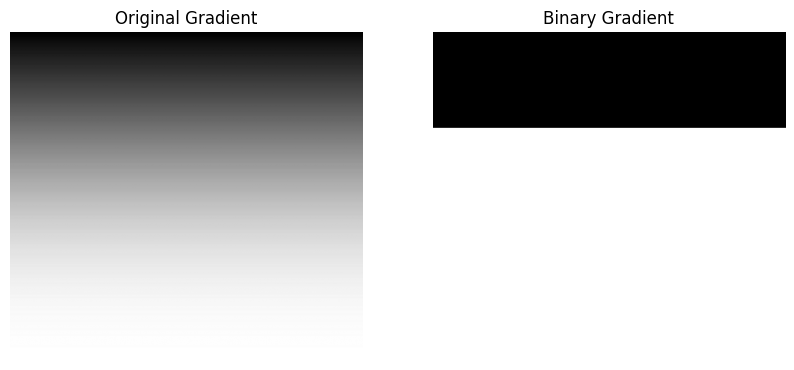

In [4]:
gradient = cv2.imread(gradient_path, cv2.IMREAD_GRAYSCALE)

if gradient is None:
  raise ValueError('Gradient Image Not Found')

threshold_value = 127
binary_gradient_numpy = np.copy(gradient)
binary_gradient_numpy[gradient < threshold_value] = 0
binary_gradient_numpy[gradient >= threshold_value] = 255

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gradient, cmap='gray')
plt.title('Original Gradient')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_gradient_numpy, cmap='gray')
plt.title('Binary Gradient')
plt.axis('off')

plt.show()

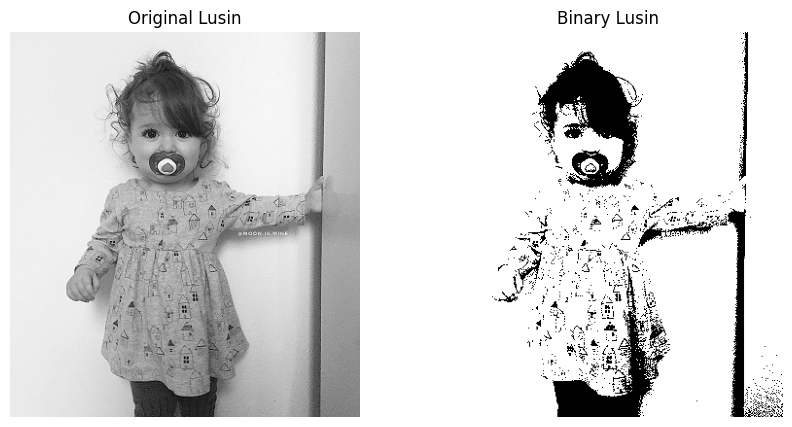

In [6]:
lusin = cv2.imread(lusin_path, cv2.IMREAD_GRAYSCALE)

if lusin is None:
  raise ValueError('Lusin Image Not Found')

binary_lusin_numpy = np.copy(lusin)
binary_lusin_numpy[lusin < threshold_value] = 0
binary_lusin_numpy[lusin >= threshold_value] = 255

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(lusin, cmap='gray')
plt.title('Original Lusin')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_lusin_numpy, cmap='gray')
plt.title('Binary Lusin')
plt.axis('off')

plt.show()

Threshold Used By OpenCV: 127.0


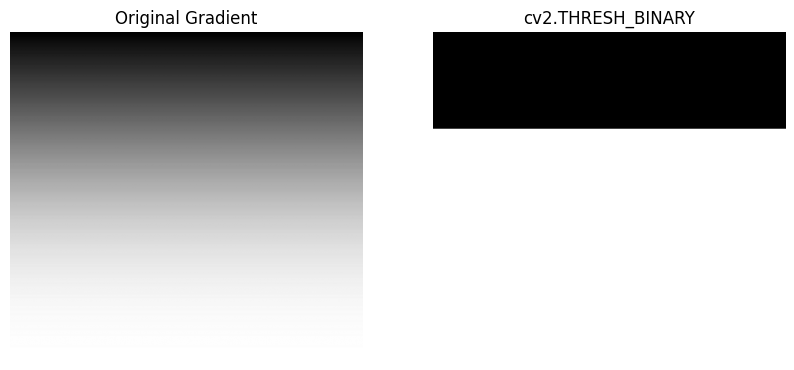

In [7]:
ret, binary_gradient_cv = cv2.threshold(gradient, 127, 255, cv2.THRESH_BINARY)
print('Threshold Used By OpenCV:', ret)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gradient, cmap='gray')
plt.title('Original Gradient')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_gradient_cv, cmap='gray')
plt.title('cv2.THRESH_BINARY')
plt.axis('off')

plt.show()

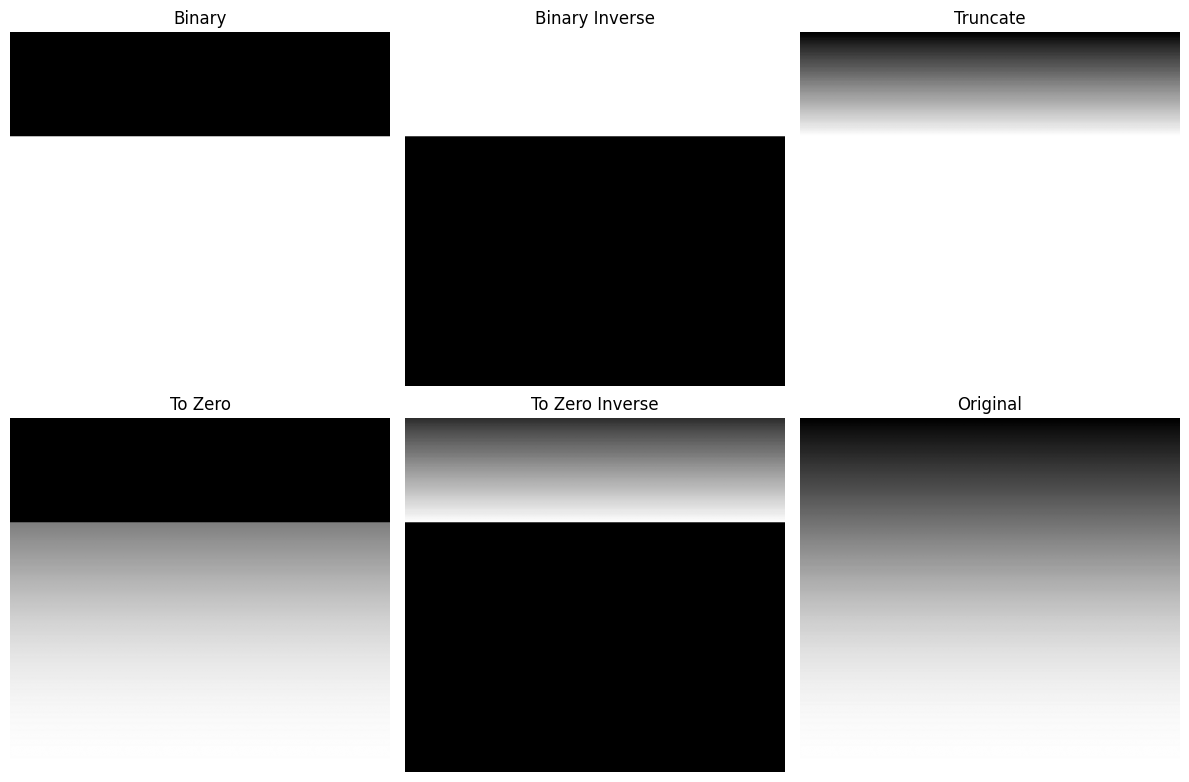

In [8]:
threshold_types = [
    ('Binary', cv2.THRESH_BINARY),
    ('Binary Inverse', cv2.THRESH_BINARY_INV),
    ('Truncate', cv2.THRESH_TRUNC),
    ('To Zero', cv2.THRESH_TOZERO),
    ('To Zero Inverse', cv2.THRESH_TOZERO_INV),
]

threshold_outputs = {}
for name, threshold_type in threshold_types:
  _, output = cv2.threshold(gradient, 127, 255, threshold_type)
  threshold_outputs[name] = output

plt.figure(figsize=(12, 8))
for index, (name, output) in enumerate(threshold_outputs.items(), start=1):
  plt.subplot(2, 3, index)
  plt.imshow(output, cmap='gray')
  plt.title(name)
  plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(gradient, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.tight_layout()
plt.show()

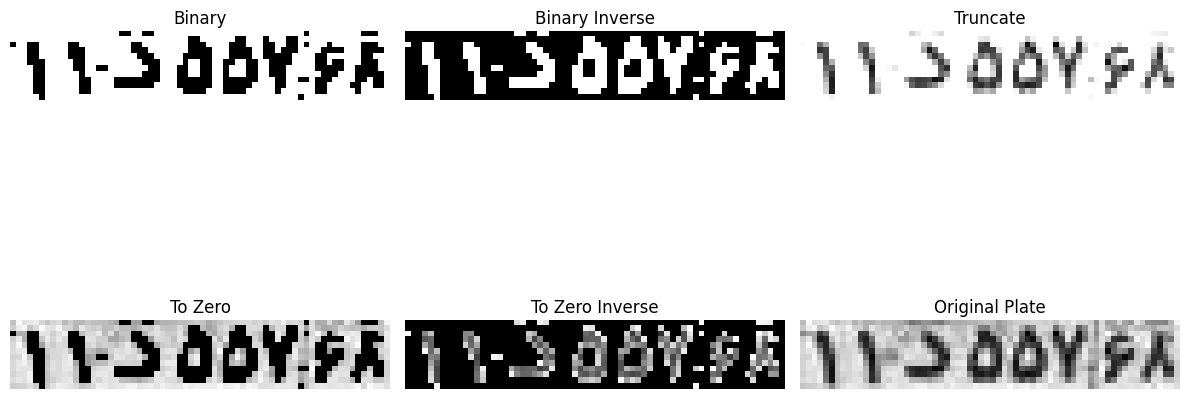

In [9]:
plate = cv2.imread(plate_path, cv2.IMREAD_GRAYSCALE)
if plate is None:
  raise ValueError('Plate Image Not Found')

plate_outputs = {}
for name, threshold_type in threshold_types:
  _, output = cv2.threshold(plate, 127, 255, threshold_type)
  plate_outputs[name] = output

plt.figure(figsize=(12, 8))
for index, (name, output) in enumerate(plate_outputs.items(), start=1):
  plt.subplot(2, 3, index)
  plt.imshow(output, cmap='gray')
  plt.title(name)
  plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(plate, cmap='gray')
plt.title('Original Plate')
plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
type_slider = widgets.IntSlider(
    value=3, min=0, max=4, step=1, description='Type'
)
value_slider = widgets.IntSlider(
    value=127, min=0, max=255, step=1, description='Value'
)
output_area = widgets.Output()

threshold_type_names = [
    'Binary',
    'Binary Inverse',
    'Truncate',
    'To Zero',
    'To Zero Inverse'
]
threshold_type_values = [
    cv2.THRESH_BINARY,
    cv2.THRESH_BINARY_INV,
    cv2.THRESH_TRUNC,
    cv2.THRESH_TOZERO,
    cv2.THRESH_TOZERO_INV
]

def threshold_demo(change=None):
  selected_type = threshold_type_values[type_slider.value]
  selected_value = value_slider.value
  _, output = cv2.threshold(plate, selected_value, 255, selected_type)

  with output_area:
    output_area.clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(plate, cmap='gray')
    plt.title('Original Plate')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(output, cmap='gray')
    plt.title(
        f'Threshold: {selected_value} | '
        f'Type: {threshold_type_names[type_slider.value]}'
    )
    plt.axis('off')

    plt.show()

type_slider.observe(threshold_demo, names='value')
value_slider.observe(threshold_demo, names='value')
display(widgets.VBox([type_slider, value_slider, output_area]))
threshold_demo()